# Final Project

Spring 2026 Data Science Project

**Contributions:**

A: Whole group decided on this idea for metallic and non-metallic products with their quantity and value.
B & C: 

- Eric contributed to Metallic/Non-metallic quantity product comparisons.
- Jon worked on the metallic/non-metallic value comparisons. 
- Tejas worked on the annual mineral quantity vs value datasets.

Minerals are an important part of Canada's economy, because they are used in construction, manufacturing, technology, trade, and a bunch of other industries. However, not all minerals contribute to the economy in the same way. Some minerals may be produced in very large quantities, but have lower shipment values, while others can have few quantities, but much higher value. As a group, we hope to take these datasets about mineral production in order to better understand how metallic and non-metallic minerals differ in production quality, shipment value, and overall economic contribution. 

**This project is guided by three main questions.**

The first being "Do metallic and non-metallic minerals differ significantly in their production quantities?". Comparing distributions helps show whether they should be analyzed together or treated as separate parts due to their differing production scales within the Canadian mining sector.

The second is "Is there a strong relationship between mineral production quantity and shipment value?". Apart from whether a material is rare or not, this question matters because it tests whether producing more of a mineral necessarily means generating more economic value. If quantity and value are weakly related, then other factors such as supply/demand, price per unit, industrial usage may be a more important factor.

The final is "Has Canada's overall mineral value changed significantly in recent years compared to 2019?". Setting aside the obvious yes/no answer, this matters because it helps identify which minerals have gained importance over the years and whether this can be evaluated in a statistically meaningful way. 

Data processing:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from scipy import stats

### Quantity and value of metallic materials (Monthly)
(Jon)
tracks monthly production quantities and shipment values for metallic minerals across Canada

In [21]:
metallic_val_df = pd.read_csv('Metallic Value.csv', skiprows=10)
metallic_val_df = metallic_val_df.iloc[:-20]
metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

metallic_val_df = metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
metallic_val_df['Value'] = pd.to_numeric(metallic_val_df['Value'].str.replace(',', ''))
metallic_val_df.dropna(inplace=True)
metallic_val_df = metallic_val_df[metallic_val_df['Value'] > 0]

metallic_mean = metallic_val_df['Value'].mean()
metallic_mean

np.float64(676947726.5590551)

In [22]:
non_metallic_val_df = pd.read_csv('Non-Metallic Value.csv', skiprows=10)
non_metallic_val_df = non_metallic_val_df.iloc[:-14]
non_metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

non_metallic_val_df = non_metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
non_metallic_val_df['Value'] = pd.to_numeric(non_metallic_val_df['Value'].str.replace(',', ''))
non_metallic_val_df.dropna(inplace=True)
non_metallic_val_df = non_metallic_val_df[non_metallic_val_df['Value'] > 0]

non_metallic_mean = non_metallic_val_df['Value'].mean()
non_metallic_mean

np.float64(131743784.64102565)

Eric Checkpoint 2: Combined metallic and non metallic (monthly)

In [23]:
def load_statcan_monthly_quantity(filename, category_name):
    df = pd.read_csv(filename, skiprows=8, header=1) # format of the csv file has some garbage lines for the first 8 rows at the top
    df["Products"] = df["Products"].ffill() # some products are NaN but they really belong to the same Product until a fresh one is listed so this just carries them down
    df = df.replace(["..", "x"], np.nan) # actually does the replacing

    df = df.melt(
        id_vars = ["Products", "Variables"],
        var_name = "REF_DATE", # month columns become reference date
        value_name = "VALUE" # their actual entries will become the value
    )

    df = df.dropna(subset=["VALUE"]).copy() # drop missing values

    df["VALUE"] = df["VALUE"].astype(str).str.replace(",", "", regex=False) # remove commas from "numbers"
    df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce") # convert value column (string) to numbers
    df = df.dropna(subset=["VALUE"]).copy() # drop rows where value failed to convert to number

    df["REF_DATE"] = pd.to_datetime(df["REF_DATE"], format="%B %Y", errors="coerce") # convert date strings to actual date time objects
    df = df.dropna(subset=["REF_DATE"]).copy() # dropping invalid dates

    df["Unit"] = df["Products"].str.extract(r"\((.*?)\)") # extract unit of measurement (metric tonnes)
    df["Product_Name"] = ( # creates a cleaner product name by removing the unit in parantheses, trailing numbers, and whitespace (that appears)
        df["Products"].str.replace(r"\s*\(.*?\)", "", regex=True)
        .str.replace(r"\s+\d+$", "", regex=True).str.strip()
    )

    df["Category"] = category_name # this is just for non-metallic vs metallic naming
    return df

# Quantity and value of annual mineral produciton (tejas)

In [24]:
df_qty = pd.read_csv('canada_annual_quantities.csv', skiprows = 8, header = 1)
df_val = pd.read_csv('canada_annual_values.csv', skiprows = 9, header = 1)

df_qty = df_qty.replace(['..', 'x'], np.nan)
df_val = df_val.replace(['..', 'x'], np.nan)

In [25]:
years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
quantities = []
values = []

for year in years:
    qty = pd.to_numeric(df_qty[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    val = pd.to_numeric(df_val[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    quantities.append(qty)
    values.append(val)

summary = pd.DataFrame({
    'Year': [int(y) for y in years],
    'Total_Quantity': quantities,
    'Total_Value_CAD_1000s': values
})

print(summary)

   Year  Total_Quantity  Total_Value_CAD_1000s
0  2019    2.165204e+09            158631345.0
1  2020    2.321877e+09            163015135.0
2  2021    2.566518e+09            191282564.0
3  2022    2.774921e+09            223359859.0
4  2023    2.705729e+09            197943726.0
5  2024    3.021890e+09            193909864.0
6  2025    1.926167e+09            180875883.0


Metallic and non metallic values (jon)

In [26]:
metallic_val_df = pd.read_csv('Metallic Value.csv', skiprows=10)
metallic_val_df = metallic_val_df.iloc[:-20]
metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

metallic_val_df = metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
metallic_val_df['Value'] = pd.to_numeric(metallic_val_df['Value'].str.replace(',', ''))
metallic_val_df.dropna(inplace=True)
metallic_val_df = metallic_val_df[metallic_val_df['Value'] > 0]

metallic_mean = metallic_val_df['Value'].mean()
metallic_mean

np.float64(676947726.5590551)

In [28]:
non_metallic_val_df = pd.read_csv('Non-Metallic Value.csv', skiprows=10)
non_metallic_val_df = non_metallic_val_df.iloc[:-14]
non_metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

non_metallic_val_df = non_metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
non_metallic_val_df['Value'] = pd.to_numeric(non_metallic_val_df['Value'].str.replace(',', ''))
non_metallic_val_df.dropna(inplace=True)
non_metallic_val_df = non_metallic_val_df[non_metallic_val_df['Value'] > 0]

non_metallic_mean = non_metallic_val_df['Value'].mean()
non_metallic_mean

np.float64(131743784.64102565)

In [29]:
metallic_df = load_statcan_monthly_quantity("1610001901-eng.csv", "Metallic")
nonmetallic_df = load_statcan_monthly_quantity("1610002001-eng.csv", "Non-metallic")

combined_df = pd.concat([metallic_df, nonmetallic_df], ignore_index=True)

quantity_df = combined_df[combined_df["Unit"].str.contains("metric tonnes", case=False, na=False)].copy()

produced_df = quantity_df[quantity_df["Variables"].str.contains("produced", case=False, na=False)].copy()

combined_produced_df = produced_df

# Average monthly production by category (eric)

Average monthly quantity produced by category:
Category
Metallic        948986.847525
Non-metallic    381142.471831
Name: VALUE, dtype: float64


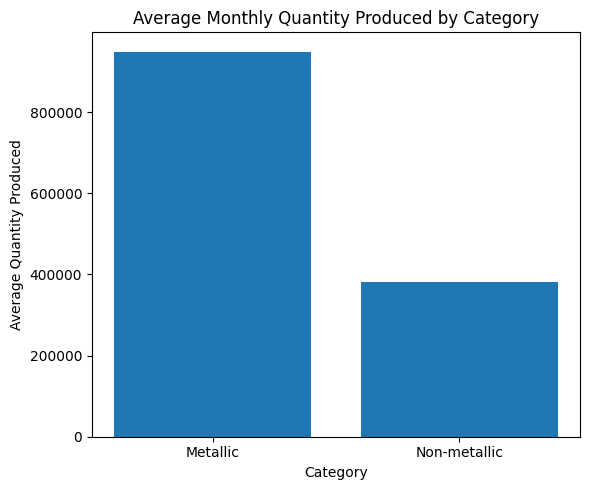

In [30]:
category_avg = ( # average monthly production for each category calculation
    produced_df.groupby("Category")["VALUE"].mean().sort_values(ascending=False)
)

print("Average monthly quantity produced by category:") # displaying averages for reference
print(category_avg)

plt.figure(figsize=(6, 5)) # plot stuff
plt.bar(category_avg.index, category_avg.values)
plt.title("Average Monthly Quantity Produced by Category")
plt.xlabel("Category")
plt.ylabel("Average Quantity Produced")
plt.tight_layout()
plt.show()

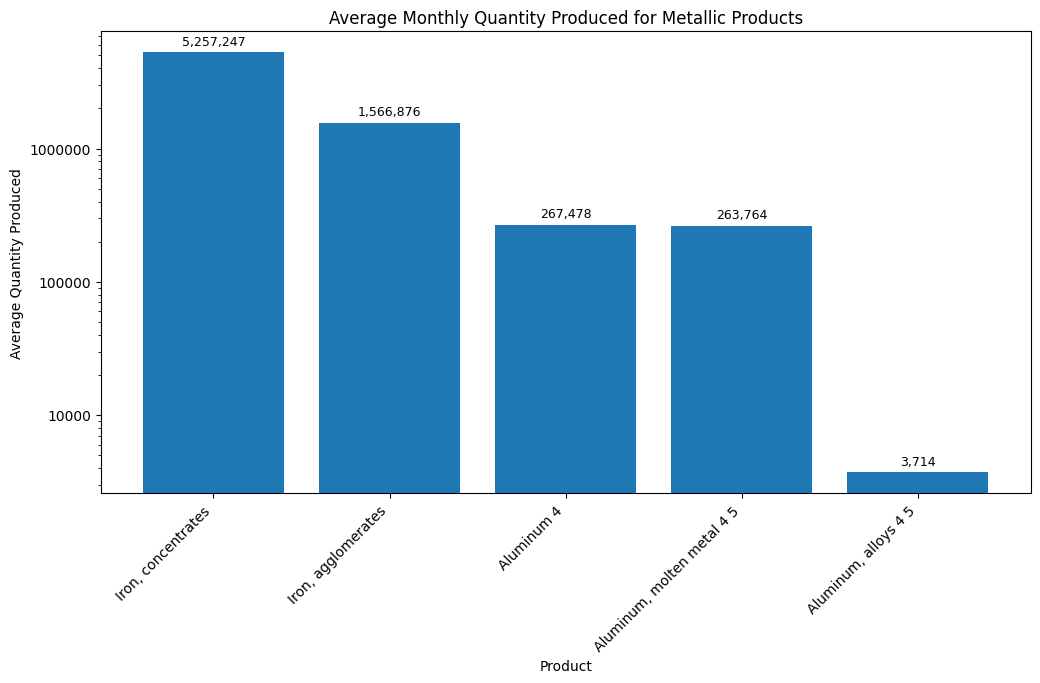

In [31]:
metallic_avg = ( # compute for average monthly production for each metallic product
    produced_df[produced_df["Category"] == "Metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

metallic_positive = metallic_avg[metallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(metallic_positive.index, metallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

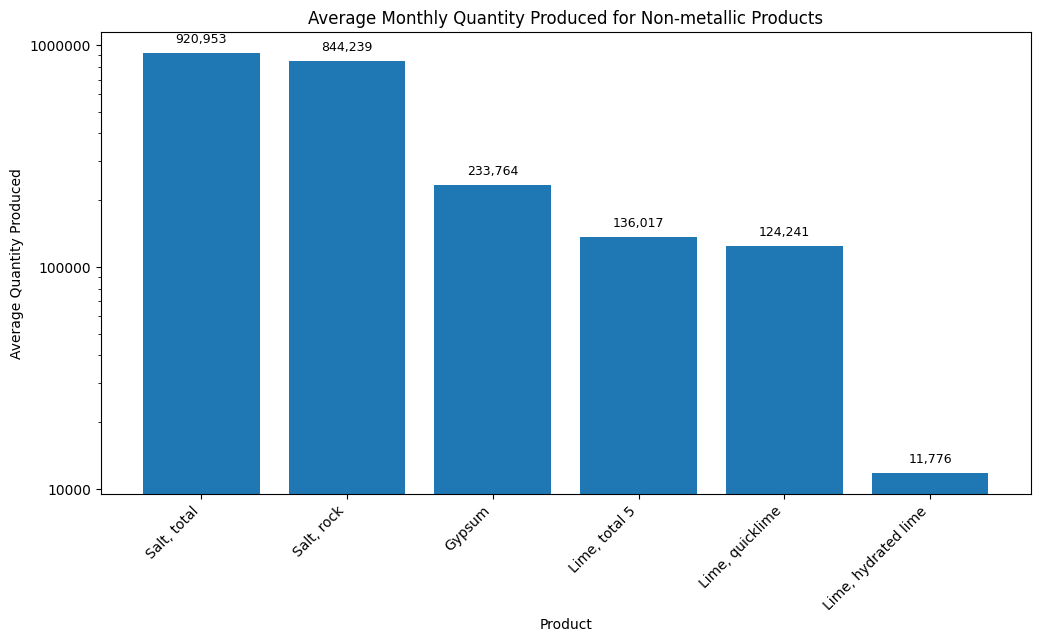

In [32]:
nonmetallic_avg = ( # compute for average monthly production for each nonmetallic product
    produced_df[produced_df["Category"] == "Non-metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

nonmetallic_positive = nonmetallic_avg[nonmetallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(nonmetallic_positive.index, nonmetallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Non-metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

Annual quantity vs Value Correlation (tejas)

In [ ]:
correlation = summary['Total_Quantity'].corr(summary['Total_Value_CAD_1000s'])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.663


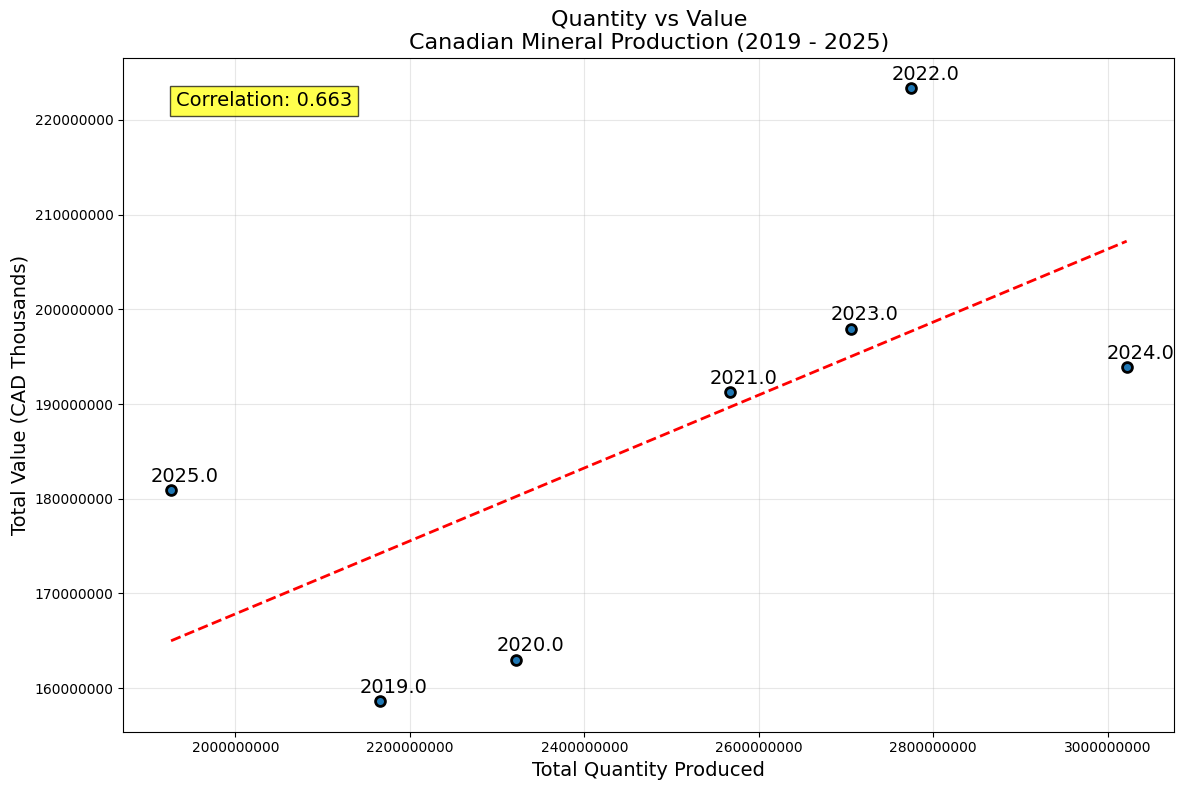

In [34]:
plt.figure(figsize = (12, 8))

plt.scatter(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], s = 50, edgecolors = 'black', linewidth = 2)

for idx, row in summary.iterrows():
    plt.annotate(
        str(row['Year']),
        (row['Total_Quantity'], row['Total_Value_CAD_1000s']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=14,
        ha='center',
        va='center'
    )
z  =  np.polyfit(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], 1)
p  =  np.poly1d(z)

x_line  =  np.linspace(summary['Total_Quantity'].min(), summary['Total_Quantity'].max(), 50)
plt.plot(x_line, p(x_line), 'r--', linewidth = 2)

plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform = plt.gca().transAxes,
         fontsize = 14, bbox = dict(facecolor = 'yellow', alpha = 0.7), verticalalignment = 'top')

plt.ticklabel_format(style = 'plain', axis = 'both')

plt.xlabel('Total Quantity Produced', fontsize = 14)
plt.ylabel('Total Value (CAD Thousands)', fontsize = 14)
plt.title('Quantity vs Value\nCanadian Mineral Production (2019 - 2025)', fontsize = 16)

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

Metallic vs non metallic value comparison (jon)

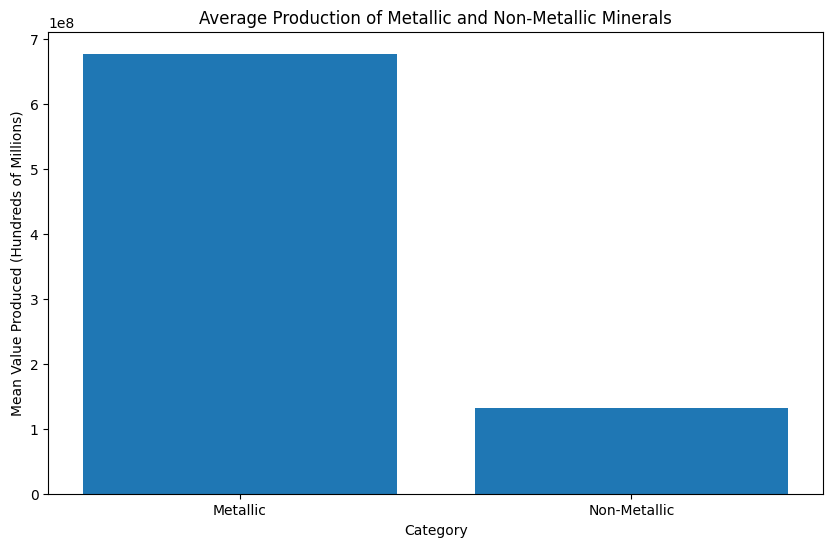

In [35]:
ids = ['Metallic', 'Non-Metallic']
mean_values = [metallic_mean, non_metallic_mean]

plt.figure(figsize=(10, 6))
plt.bar(ids, mean_values)
plt.title('Average Production of Metallic and Non-Metallic Minerals')
plt.xlabel('Category')
plt.ylabel('Mean Value Produced (Hundreds of Millions)')
plt.yticks
plt.show()

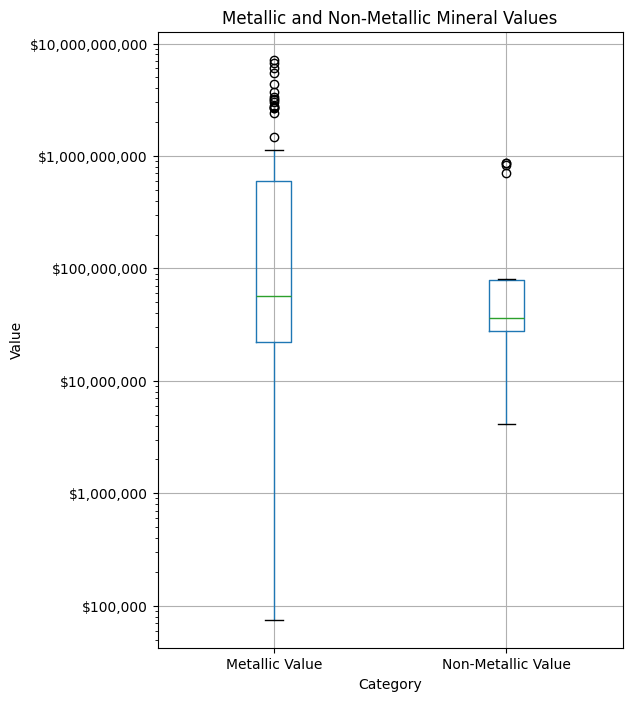

In [36]:
values_df = pd.DataFrame()
values_df['Metallic Value'] = metallic_val_df['Value']
values_df['Non-Metallic Value'] = non_metallic_val_df['Value']
boxplot = values_df.boxplot(column=['Metallic Value', 'Non-Metallic Value'], figsize=(6, 8))
plt.title('Metallic and Non-Metallic Mineral Values')
plt.xlabel('Category')
plt.ylabel('Value')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

## Conclusion 1: Metallic minerals are produced in different quantities than non metallic materials

**Mann-Whitney U test** to determine whether difference is statistically significant

Null hypothesis: Distribution is same for metallic and non metallic minerals

Alternative hypothesis: Distribution is different

In [37]:
metallic_values = combined_produced_df[combined_produced_df["Category"] == "Metallic"]["VALUE"].dropna()
nonmetallic_values = combined_produced_df[combined_produced_df["Category"] == "Non-metallic"]["VALUE"].dropna()

print(f"Metallic observations: {len(metallic_values)}")
print(f"Non-metallic observations: {len(nonmetallic_values)}")
print(f"\nMetallic median: {metallic_values.median():,.0f}")
print(f"Non-metallic median: {nonmetallic_values.median():,.0f}")
print(f"Metallic mean: {metallic_values.mean():,.0f}")
print(f"Non-metallic mean: {nonmetallic_values.mean():,.0f}")

# test
u_stat, p_value = stats.mannwhitneyu(metallic_values, nonmetallic_values, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_value:.6f}")




Metallic observations: 505
Non-metallic observations: 426

Metallic median: 238,002
Non-metallic median: 157,898
Metallic mean: 948,987
Non-metallic mean: 381,142

Mann-Whitney U statistic: 84,898
p-value: 0.000000


Due to p-value under 0.05, we can conclude that the difference in production quantity distributions of metallic and non-metallic minerals are significant, which means that the two categories represent different scales of production in Canada's mining sector.

## Conclusion 2: Production quantity and shipment value are not strongly correlated among metallic minerals

**Pearson correlation w/ hypothesis test** to determine whether statistically significant

Null hypothesis: No linear association between avg monthly quantity and avg monthly value (p = 0)

Alternative hypothesis: There is linear association (p != 0)

In [38]:
# Using tejas data, match quantity produced with value per mineral
import re

df_qty['Products'] = df_qty['Products'].ffill()
df_qty['Variables'] = df_qty['Variables'].ffill()
qty_produced_annual = df_qty[df_qty['Variables'] == 'Quantity produced'].copy()

def clean_name(s):
    s = re.sub(r'\s*\(.*?\)', '', str(s))
    s = re.sub(r'(\s+\d+)+$', '', s)
    return s.lower().strip()

years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

qty_avgs = {}
for _, row in qty_produced_annual.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        qty_avgs[clean_name(row['Products'])] = np.mean(vals)

val_avgs = {}
for _, row in df_val.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        val_avgs[clean_name(row['Products'])] = np.mean(vals)

common = set(qty_avgs.keys()) & set(val_avgs.keys())
common = {k for k in common if qty_avgs[k] > 0 and val_avgs[k] > 0}

paired_df = pd.DataFrame({
    'AvgQuantity': [qty_avgs[k] for k in common],
    'AvgValue': [val_avgs[k] for k in common]
}, index=list(common))

print(f"Matched minerals with both quantity and value: {len(paired_df)}")

r_pearson, p_pearson = stats.pearsonr(paired_df['AvgQuantity'], paired_df['AvgValue'])
print(f"\nPearson r = {r_pearson:.4f}")
print(f"p-value = {p_pearson:.6f}")


Matched minerals with both quantity and value: 50

Pearson r = 0.0470
p-value = 0.745653


Pearson r ≈ 0.05 with p = 0.75,  therefore no linear relationship between how much of a mineral Canada produces and how much revenue it generates.

## Conclusion 3: Recent overall mineral production is significantly different from 2019

Use **One-sample t-test**

Null hypothesis: Mean total value from 2020-2025 is same as 2019 total value


Alternative hypothesis: Mean total v alue from 2020-2025 is different from 2019 total value

In [39]:
# Using tejas DataFrame
print("Year-over-year totals:")
print(summary.to_string(index=False))

baseline_value = summary.loc[summary['Year'] == 2019, 'Total_Value_CAD_1000s'].values[0]
print(f"\n2019 baseline total value (CAD thousands): {baseline_value:,.0f}")

later_years_values = summary.loc[summary['Year'] > 2019, 'Total_Value_CAD_1000s'].values
print(f"2020-2025 values: {later_years_values}")
print(f"Mean of 2020-2025: {later_years_values.mean():,.0f}")

t_stat, p_value = stats.ttest_1samp(later_years_values, baseline_value)
print(f"\nOne-sample t-test:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


Year-over-year totals:
 Year  Total_Quantity  Total_Value_CAD_1000s
 2019    2165203912.0            158631345.0
 2020    2321876634.0            163015135.0
 2021    2566517536.0            191282564.0
 2022    2774920555.0            223359859.0
 2023    2705728700.0            197943726.0
 2024    3021889806.0            193909864.0
 2025    1926166504.0            180875883.0

2019 baseline total value (CAD thousands): 158,631,345
2020-2025 values: [1.63015135e+08 1.91282564e+08 2.23359859e+08 1.97943726e+08
 1.93909864e+08 1.80875883e+08]
Mean of 2020-2025: 191,731,172

One-sample t-test:
t-statistic: 4.0678
p-value: 0.0097


With signifiance level of 0.05, we reject null hypothesis. This confirms that the average total mineral value from 2020–2025 is significantly higher than the 2019 baseline which means Canada's mineral sector experienced an increase in total economic output.